In [3]:
import numpy as np
import matplotlib.pyplot as plt
from vectorHASH_cont import scaffold_layers, sensory_weights, relu
from scipy.integrate import solve_ivp

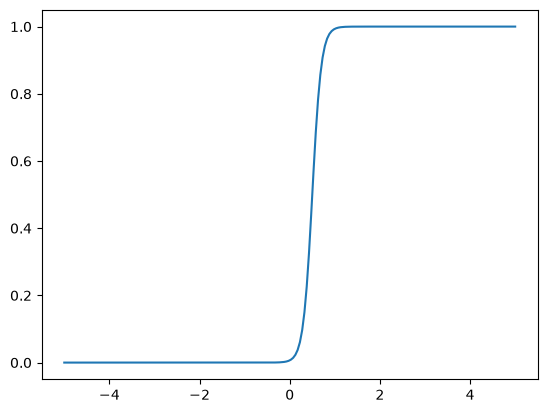

In [151]:
def gridtogrid(exc, inh, lambdas):
    """
    Makes the weight matrix for grid CAN dynamics with self excitation and lateral inhibition
    """
    # make sure lambdas is an np array
    lambdas = np.asarray(lambdas)
    Ng = np.sum(lambdas*lambdas)
    W_gg = np.zeros((Ng, Ng))
    i = 0

    for lam in lambdas:
        size = lam**2
        W_gg[i:i+size, i:i+size] = inh
        i += size

    np.fill_diagonal(W_gg, exc)
    return W_gg

def sigmoid(x, beta):
    return 1 / (1 + np.exp(-beta * x + 5))

x = np.linspace(-5,5,200)
plt.plot(x, sigmoid(x, 10))
plt.show()


In [117]:
lams = np.array([2,3])          # grid periods
Ng = np.sum(lams*lams)              # number of grid units
patts_total = np.prod(lams*lams)    # total number of patterns possible to store
Nh = 200                            # number of hc units
Ns = patts_total   

W_gg = gridtogrid(1.2, -0.5, lams)
print(W_gg)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0)
"""sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens, hc)"""

# testing the weight matrix: grid state should stay at fixed point
g = grid[:, 34]
print("0 state:", np.argmax(g[:4]), np.argmax(g[4:]))

for i in range(3):
    g1 = sigmoid(W_gg @ g, 10)
    print(f"{i+1} state:", np.argmax(g1[:4]), np.argmax(g1[4:]))


[[ 1.2 -0.5 -0.5 -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [-0.5  1.2 -0.5 -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [-0.5 -0.5  1.2 -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [-0.5 -0.5 -0.5  1.2  0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   1.2 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5  1.2 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5  1.2 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5 -0.5  1.2 -0.5 -0.5 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5 -0.5 -0.5  1.2 -0.5 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5 -0.5 -0.5 -0.5  1.2 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5 -0.5 -0.5 -0.5 -0.5  1.2 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5  1.2 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5  1.2]]
0 state: 2 7
1 state: 2 7
2 state: 2 7
3 state: 2 7


In [ ]:
print(g1, W_gg@g1)

In [154]:
def scaffold(t, state, Ng, Nh, W_gg, W_hg, W_gh, theta, tau_g, tau_h, beta=10):
    g = state[:Ng]
    h = state[Ng:]

    dg = (-g + sigmoid(W_gg @ g + 1*W_gh @ h, beta)) / tau_g
    dh = (-h + relu(W_hg @ g - theta)) / tau_h

    return np.concatenate([dg, dh])

# if intial state is a fixed point, should stay at that fixed point
g0 = grid[:, 0] 
h0 = hc[:,0]
state0 = np.concatenate([g0, h0])

sol = solve_ivp(
    scaffold, t_span=(0, 50), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, 0, 0.5, 1.0),
    method='RK45', t_eval=np.linspace(0, 50, 500)
)

g_traj = sol.y[:Ng, :]   # shape (Ng, n_timepoints)
h_traj = sol.y[Ng:, :]

print(g_traj[:, -1],grid[:,0])
print(np.allclose(h0, h_traj[:, -1]))


[1.         0.99997929 0.99997929 0.99997929 1.         0.99997929
 0.99997929 0.99997929 0.99997929 0.99997929 0.99997928 0.99997929
 0.99997929] [1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
False
